In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn import metrics



In [7]:
# Load the raw solar electrolyzer sensor dataset
df = pd.read_csv('../data/ROSS_data_20201010.csv')
df.head()

,Date,time,lab_temperature,reactor_temperature,current,voltage,power
0,10/10/2020,7:42:06,15.69,15.77,4.39,27.18,119.31
1,10/10/2020,7:42:18,15.73,15.75,4.64,26.93,125.03
2,10/10/2020,7:42:43,15.73,15.71,3.68,26.97,99.35
3,10/10/2020,7:42:57,15.75,15.77,3.84,26.95,103.36
4,10/10/2020,7:43:12,15.77,15.75,4.59,26.96,123.82


In [ ]:
# Show basic statistics like mean, min, and max for each column
# Note: A noticeable difference between the mean (average) and the 50% mark (median) 
# for 'current' and 'reactor_temperature' points to spikes or outliers in the data.
df.describe()

,lab_temperature,reactor_temperature,current,voltage,power,current_lag,current_lead
count,2972.000000,2972.000000,2972.000000,2972.000000,2972.000000,2971.000000,2971.000000
mean,18.516157,21.732476,7.326938,26.348721,191.239425,7.328758,7.327927
std,1.491019,3.272626,2.745331,0.678290,67.218289,2.743999,2.745264
min,15.690000,15.670000,1.710000,24.820000,47.760000,1.710000,1.710000
25%,17.150000,18.750000,5.400000,25.930000,144.680000,5.400000,5.400000
50%,18.550000,22.230000,6.660000,26.360000,175.650000,6.660000,6.660000
75%,19.770000,24.830000,9.190000,26.790000,238.370000,9.190000,9.190000
max,21.390000,26.470000,14.840000,27.900000,371.230000,14.840000,14.840000


In [ ]:
# Count the number of missing (NaN) values in each column
print(df.isnull().sum())

Date                   0
time                   0
lab_temperature        0
reactor_temperature    0
current                0
voltage                0
power                  0
current_lag            1
current_lead           1
dtype: int64


In [ ]:
# Make a backup copy of the raw data for a before-and-after graph later
df_raw_data = df.copy()
df_raw_data['Date_time'] = df_raw_data['Date'].astype(str) + ' ' + df_raw_data['time'].astype(str)
df_raw_data['Timestamp'] = pd.to_datetime(df_raw_data['Date_time'])
df_raw_data = df_raw_data.set_index('Timestamp')

# Create new columns for the previous row (lag) and next row (lead) 
# This helps compare each data point with its immediate neighbors
df['current_lag'] = df['current'].shift(1)
df['current_lead'] = df['current'].shift(-1)


In [ ]:
# Check for severe downward spikes in the current values
# This finds rows where the current drops drastically lower than its neighbors
downward_spike_check = df[df['current'] < ((df['current_lag'] + df['current_lead'])/2) - 10]
print(downward_spike_check)


Empty DataFrame
Columns: [Date, time, lab_temperature, reactor_temperature, current, voltage, power, current_lag, current_lead]
Index: []


In [ ]:
# The result above shows there are no downward spike checks. 

# Now, filter out upward sensor spikes caused by reactor overheating
# This keeps only the rows where the current is normal compared to its neighbors
df_clean = df[df['current'] <= ((df['current_lag'] + df['current_lead']) / 2) + (2/3)]


# Remove the temporary lag and lead helper columns since filtering is one
df_clean = df_clean.drop(['current_lag', 'current_lead'], axis=1) 


# Combine the separate Date and time text columns into a single column
df_clean['Date_time'] = df_clean['Date'].astype(str) + ' ' + df_clean['time'].astype(str)

# Convert the combined text column into a standard datetime format that pandas can use
df_clean['timestamp'] = pd.to_datetime(df_clean['Date_time'])

# Extract hours and minutes as separate features for the machine learning models
df_clean['hour'] = df_clean['timestamp'].dt.hour
df_clean['minute'] = df_clean['timestamp'].dt.minute

# Set the timestamp column as the index and sort chronologically
df_clean = df_clean.set_index('timestamp')
df_clean = df_clean.sort_index()

# Drop the redundant text columns to keep the dataset clean
df_clean = df_clean.drop(columns =['Date', 'time', 'Date_time'])
print(df_clean)

                     lab_temperature  reactor_temperature  current  voltage  \
timestamp                                                                     
2020-10-10 07:42:18            15.73                15.75     4.64    26.93   
2020-10-10 07:42:43            15.73                15.71     3.68    26.97   
2020-10-10 07:42:57            15.75                15.77     3.84    26.95   
2020-10-10 07:43:24            15.75                15.77     3.84    26.92   
2020-10-10 07:43:35            15.77                15.75     4.04    26.90   
...                              ...                  ...      ...      ...   
2020-10-10 17:35:01            18.43                22.07     1.87    27.86   
2020-10-10 17:35:16            18.49                22.13     1.92    27.86   
2020-10-10 17:35:38            18.45                22.07     1.71    27.87   
2020-10-10 17:35:54            18.43                21.95     1.92    27.88   
2020-10-10 17:36:05            18.45                

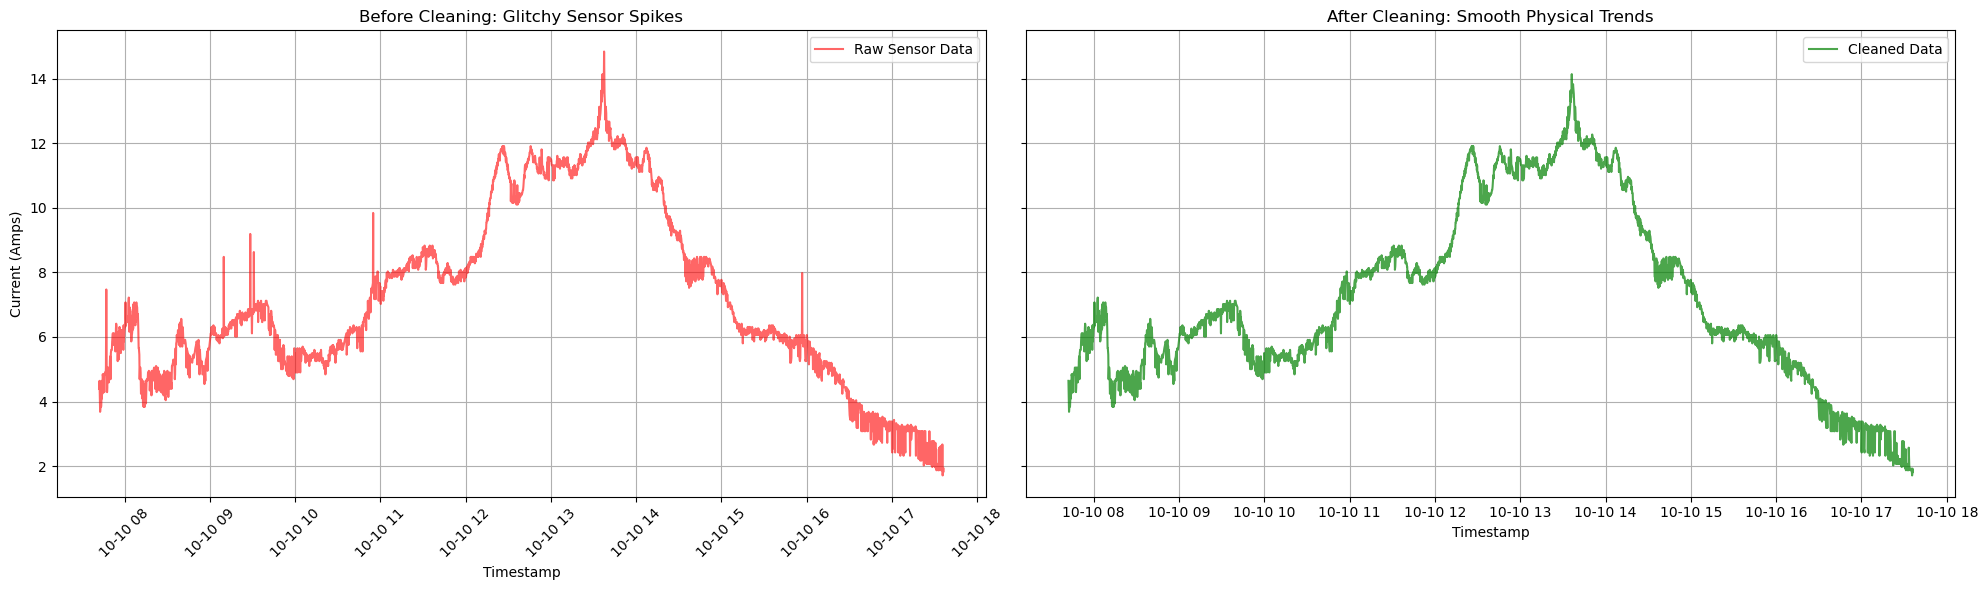

In [ ]:
# Fill any blank spaces created by the filtering process using linear interpolation
# This connects the missing data points using a straight line

df_clean = df_clean.interpolate(method='linear')

# Plot the raw data against the cleaned data to visualize the results
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (20,6), sharey= True)

ax1.plot(df_raw_data.index, df_raw_data['current'], color = 'red', alpha=0.6, label='Raw Sensor Data')
ax1.set_title('Before Cleaning: Glitchy Sensor Spikes')
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Current (Amps)')
ax1.grid(True)
ax1.legend()
plt.setp(ax1.get_xticklabels(), rotation = 45)

ax2.plot(df_clean.index, df_clean['current'], color = 'green', alpha=0.7, label = 'Cleaned Data')
ax2.set_title('After Cleaning: Smooth Physical Trends')
ax2.set_xlabel('Timestamp')
ax2.grid(True)
ax2.legend()
plt.setp(ax2.get_yticklabels(), rotation = 45)

plt.tight_layout()

# Add the line below to save the image to a file in the current directory with a high resolution of 300 dpi and tight layout to avoid cutting off labels
# plt.savefig('electrolyzer_cleaning_comparison.png', dpi=300, bbox_inches='tight')

plt.show()

In [37]:
# CALCULATING THEORETICAL HYDROGEN PRODUCTION
# =================
# Faraday's first law of electrolysis calculates the theoretical mass 
# of hydrogen gas produced using the formula:
# m = (I * t * M) / (z * F)
#
# Where:
# m = Mass of hydrogen produced theoretically (grams)
# M = Molar mass of hydrogen gas (2.016 g/mol)
# I = Current in Amperes (Amps)
# t = Time in seconds (has to be calculated)
# z = Valency of H2 gas (2)
# F = Faraday's constant (96,485 C/mol)


# Calculate the time gap in seconds between consecutive sensor logs
df_clean['seconds'] = df_clean.index.to_series().diff()
df_clean['seconds'] = df_clean['seconds'].dt.total_seconds()

# The first row becomes NaN because it has no previous row to subtract from.
# This missing value is filled using the median time gap of the 'seconds' column.
df_clean['seconds'] = df_clean['seconds'].fillna(df_clean['seconds'].median())


# Apply Faraday's Law formula to calculate theoretical hydrogen mass (grams)
I = df_clean['current']
t = df_clean['seconds']
M = 2.016
z = 2
F = 96485
m = (I * t * M) / (z * F)

df_clean['H2_theoretical(g)'] = m

print(df_clean['H2_theoretical(g)'])

timestamp
2020-10-10 07:42:18    0.000533
2020-10-10 07:42:43    0.000961
2020-10-10 07:42:57    0.000562
2020-10-10 07:43:24    0.001083
2020-10-10 07:43:35    0.000464
                         ...   
2020-10-10 17:35:01    0.000234
2020-10-10 17:35:16    0.000301
2020-10-10 17:35:38    0.000393
2020-10-10 17:35:54    0.000321
2020-10-10 17:36:05    0.000208
Name: H2_theoretical(g), Length: 2942, dtype: float64


In [26]:
# 2. GENERATING REALISTIC SYSTEM EFFICIENCY AND ACTUAL YIELD
# ====================
# Real-world machines do not operate at 100% efficiency due to heat loss.
# Since the original dataset does not contain actual hydrogen measurements, synthetic
# target values are generated to simulate realistic operation.

# Create a random normal distribution around a realistic baseline/average of 84% efficiency
np.random.seed(42)
df_clean['efficiency(%)'] = 84 + np.random.normal(0, 3, len(df_clean))

# Restrict efficiency values to a strict physical range between 70% and 93%
df_clean['efficiency(%)'] = df_clean['efficiency(%)'].clip(70, 93)


# Calculate actual hydrogen production using the efficiency formula:

# Actual Hydrogen gas produced = (Efficiency * Theoretical Hydrogen Output) / 100
df_clean['H2_actual(g)'] = (df_clean['efficiency(%)'] * df_clean['H2_theoretical(g)']) / 100
print(df_clean.columns)


Index(['lab_temperature', 'reactor_temperature', 'current', 'voltage', 'power',
       'hour', 'minute', 'seconds', 'H2_theoretical(g)', 'efficiency(%)',
       'H2_actual(g)'],
      dtype='str')


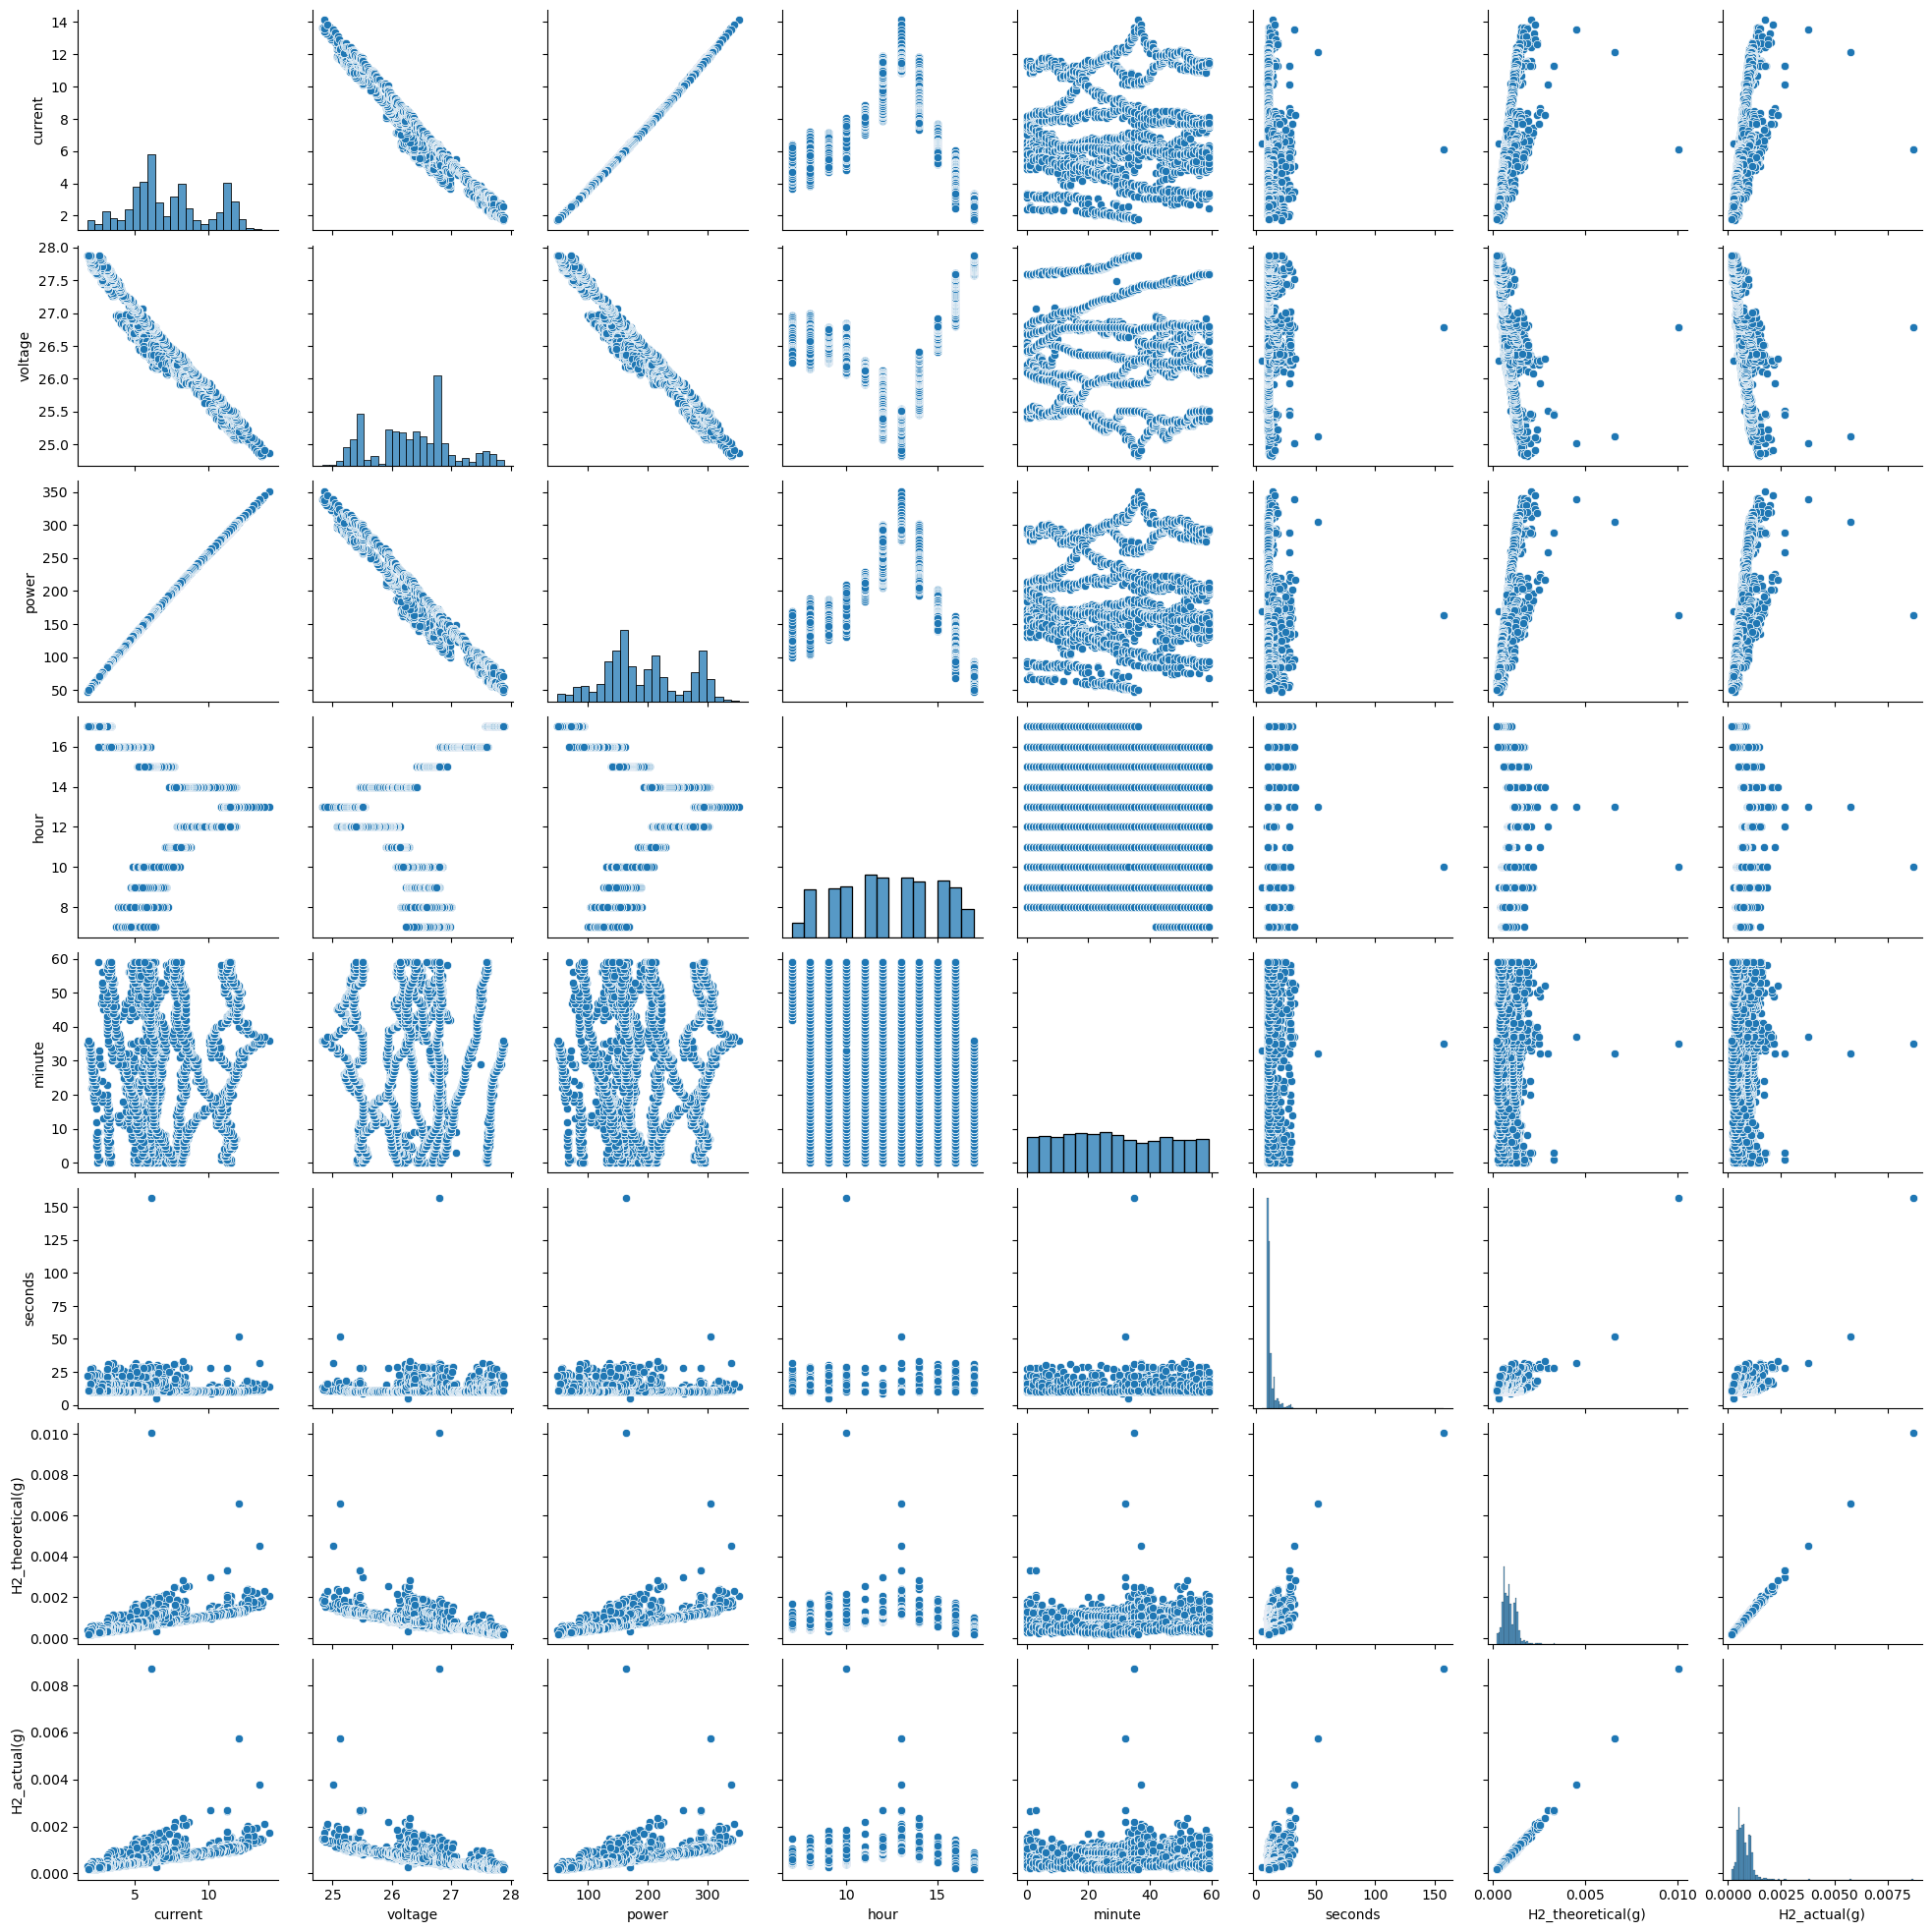

In [27]:
# 3. FEATURE SELECTION & CORRELATION ANALYSIS
# ==================
# Analyze relationships between features before starting model training.
# The 'efficiency' column is dropped to prevent the model from "cheating,"
# as efficiency directly unlocks the final actual hydrogen value.

# Generate visual scatter plots across features using a pairplot
sns.pairplot(df_clean.drop(['lab_temperature', 'reactor_temperature', 'efficiency(%)'], axis=1))


In [28]:

# Now, generate a correlation matrix to check relationship strengths
df_clean.drop(['lab_temperature', 'reactor_temperature', 'efficiency(%)'], axis=1).corr()

# Note: From the results, Hour and minute show lower mathematical correlation with hydrogen output.
# However, they are kept in the training features because time-of-day impacts 
# the photovoltaic electrolyzer.

,current,voltage,power,hour,minute,seconds,H2_theoretical(g),H2_actual(g)
current,1.000000,-0.974423,0.999639,-0.041708,0.002387,-0.202518,0.672254,0.665748
voltage,-0.974423,1.000000,-0.973439,0.232353,-0.017387,0.193009,-0.663858,-0.657768
power,0.999639,-0.973439,1.000000,-0.042836,0.000465,-0.204157,0.671653,0.665094
hour,-0.041708,0.232353,-0.042836,1.000000,-0.109103,-0.038933,-0.087851,-0.086818
minute,0.002387,-0.017387,0.000465,-0.109103,1.000000,0.098837,0.084265,0.083779
seconds,-0.202518,0.193009,-0.204157,-0.038933,0.098837,1.000000,0.553226,0.555540
H2_theoretical(g),0.672254,-0.663858,0.671653,-0.087851,0.084265,0.553226,1.000000,0.996474
H2_actual(g),0.665748,-0.657768,0.665094,-0.086818,0.083779,0.555540,0.996474,1.000000


In [29]:
# 4. DATA SPLITTING USING TRAIN-TEST SPLIT
# =============
# Separate independent inputs (X) from the dependent target variable (y)
X = df_clean[['lab_temperature', 'reactor_temperature', 'current', 'voltage', 'power', 
             'hour', 'minute', 'seconds']]
y = df_clean['H2_actual(g)']


# Split data into 70% for training the models and 30% for testing them
# But avoid splitting randomly since it's a time-series dataset. Instead, split chronologically.
split_data = int(len(df_clean)* 0.7)

X_train = X.iloc[0: split_data]
X_test = X.iloc[split_data: ]

y_train = y.iloc[0:split_data]
y_test = y.iloc[split_data: ]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# MODEL TRAINING
# FIRST MODEL: LINEAR REGRESSION
# ================
# Initialize and train a baseline Linear Regression model
lm = LinearRegression()
lm.fit(X_train, y_train)

# The intercept/bias (b) as in the formula: f(x)= wx+b
# If every single input feature reading were exactly zero, the hydrogen output would be this intercept value. 
print("The intercept/bias is:", lm.intercept_)

# Extract the weights (coefficients) assigned to each input feature and convert into a DataFrame for better readability
df_clean_weight = pd.DataFrame(lm.coef_, X.columns, columns=['Weights (Coeff)'])
print(df_clean_weight)

# Generate predictions using the unseen test data
lm_predictions = lm.predict(X_test)

The intercept/bias is: 0.002963509210121485
                     Weights (Coeff)
lab_temperature        -9.022502e-06
reactor_temperature     1.186682e-05
current                -1.576019e-05
voltage                -1.317146e-04
power                   3.477548e-06
hour                   -4.913892e-06
minute                  1.091693e-07
seconds                 5.625155e-05


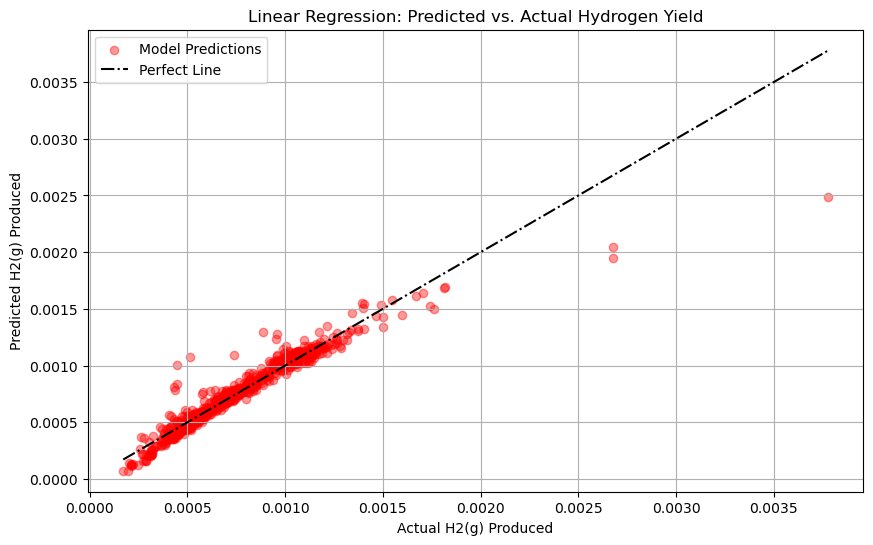

In [ ]:
# VISUALIZING THE LINEAR MODEL PREDICTIONS
# ================
# Plot a scatter chart to see how closely the predictions match actual data
plt.figure(figsize=(10,6))

plt.scatter(y_test, lm_predictions, color='red', alpha=0.4, label='Model Predictions')

# Draw a 45-degree diagonal reference line representing perfect predictions
pred_line = np.linspace(min(y_test), max(y_test), 100) 
plt.plot(pred_line, pred_line, color='black', linestyle='-.', label='Perfect Line') 

# Finalize chart details
plt.title('Linear Regression: Predicted vs. Actual Hydrogen Yield')
plt.xlabel('Actual H2(g) Produced')
plt.ylabel('Predicted H2(g) Produced')


# To Save the image to the current folder:
# plt.savefig('linear_regression_predictions.png', dpi=300, bbox_inches='tight')

plt.grid(True)
plt.legend()
plt.show()

In [33]:
# METRIC EVALUATION
# =============
# Calculate standard metrics to evaluate model performance

# Mean Absolute Error (MAE) measures the average size of the prediction errors
MAE = metrics.mean_absolute_error(y_test, lm_predictions)
print(f'The Mean Absolute Error is: {MAE}')

# Root Mean Squared Error (RMSE) measures error size while penalizing larger mistakes
MSE = metrics.mean_squared_error(y_test, lm_predictions)
RMSE = np.sqrt(MSE)
print(f'The Root Mean Squared Error is: {RMSE}')

# R-squared (Variance) measures the percentage of data patterns captured by the model
Variance = metrics.explained_variance_score(y_test, lm_predictions)
print(f'The Variance (R^2) is: {Variance}')

The Mean Absolute Error is: 4.470593823908662e-05
The Root Mean Squared Error is: 8.465027950642026e-05
The Variance (R^2) is: 0.9256344378289946


In [ ]:
# - LINEAR REGRESSION TAKEAWAYS -
# 1. An R^2 score of 92.56% means the linear model explains a huge portion of the data patterns.
#    This confirms that the core electrical relationship (Faraday's Law) is incredibly strong.
# 2. The remaining 7.44% of unexplained variance likely stems from subtle non-linear curves.
# 3. An MAE of 0.0000447 grams means that on average, predictions are off by a tiny fraction of a gram.


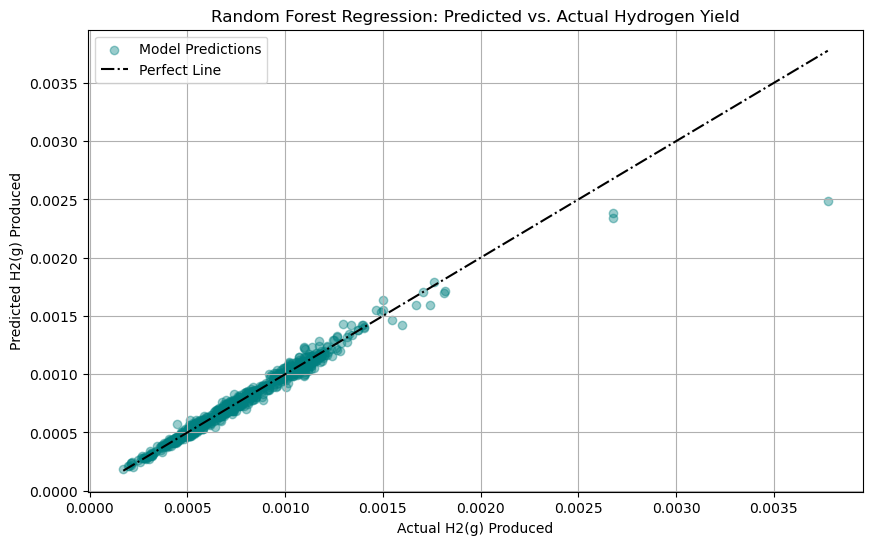

In [39]:
# SECOND MODEL: RANDOM FOREST REGRESSOR
# Initialize and train the Random Forest model using 100 decision trees

rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_train, y_train)

# Generate predictions using the unseen test data
rfr_prediction = rfr.predict(X_test)

# Plot a scatter chart to see how closely the predictions match actual data
plt.figure(figsize=(10,6))
plt.scatter(y_test, rfr_prediction, color='teal', alpha=0.4, label='Model Predictions')

# Draw a diagonal reference line representing perfect predictions
pred_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(pred_line, pred_line, color='black', linestyle='-.', label='Perfect Line')

plt.title('Random Forest Regression: Predicted vs. Actual Hydrogen Yield')
plt.xlabel('Actual H2(g) Produced')
plt.ylabel('Predicted H2(g) Produced')

# To Save the image to the current folder:
plt.savefig('random_forest_regression_predictions.png', dpi=300, bbox_inches='tight')

plt.grid(True)
plt.legend()
plt.show()


In [40]:
# Calculate standard metrics to evaluate model performance
# Mean Absolute Error (MAE) measures the average size of the prediction errors
MAE = metrics.mean_absolute_error(y_test, rfr_prediction)
print(f'The Mean Absolute Error is: {MAE}')

# Root Mean Squared Error (RMSE) measures error size while penalizing larger mistakes
RMSE = np.sqrt(metrics.mean_squared_error(y_test, rfr_prediction))
print(f'The Root Mean Squared Error is: {RMSE}')

# R-squared (Variance) measures the percentage of data patterns captured by the model
Variance = metrics.explained_variance_score(y_test, rfr_prediction)
print(f'The Variance (R^2) is: {Variance}')

The Mean Absolute Error is: 2.7098665220446094e-05
The Root Mean Squared Error is: 5.72913517284936e-05
The Variance (R^2) is: 0.9660243737112519


In [49]:
# - RANDOM FOREST TAKEAWAYS -
# 1. The R^2 accuracy score increased to a project-peak of 96.60% (up from Linear Regression's 92.56%).
#    This improvement proves that capturing non-linear thermal curves and solar cycles matters.
# 2. The lower RMSE score (0.0000573) shows that the ensemble averaging approach of decision trees 
#    successfully smoothed out sudden operational sensor noise and eliminated wild outlier errors.
# 3. The MAE dropped to a project-low of 0.0000271 grams.

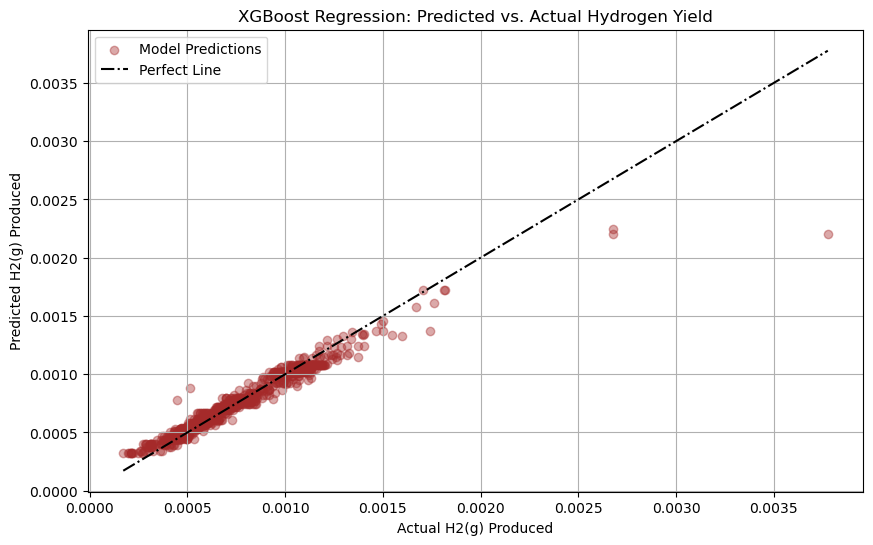

In [47]:
# THIRD MODEL: XGBOOST REGRESSOR
# Initialize and train the Extreme Gradient Boosting model using default parameters
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)

# Generate predictions on the test set
xgb_prediction = xgb.predict(X_test)

# Plot a scatter chart to see how closely the predictions match actual data
plt.figure(figsize=(10,6))
plt.scatter(y_test, xgb_prediction, color='brown', alpha=0.4, label='Model Predictions')

perfect_line = np.linspace(min(y_test), max(y_test), 100)
plt.plot(perfect_line, perfect_line, color='black', linestyle='-.', label='Perfect Line')

plt.title('XGBoost Regression: Predicted vs. Actual Hydrogen Yield')
plt.xlabel('Actual H2(g) Produced')
plt.ylabel('Predicted H2(g) Produced')

# To Save the image to the current directory:
plt.savefig('xgb_regression_predictions.png', dpi=300, bbox_inches='tight')

plt.grid(True)
plt.legend()
plt.show()


In [48]:
# Calculate standard metrics to evaluate model performance
# Mean Absolute Error (MAE) measures the average size of the prediction errors
MAE = metrics.mean_absolute_error(y_test, xgb_prediction)
print(f'The Mean Absolute Error is: {MAE}')

# Root Mean Squared Error (RMSE) measures error size while penalizing larger mistakes
RMSE = np.sqrt(metrics.mean_squared_error(y_test, xgb_prediction))
print(f'The Root Mean Squared Error is: {RMSE}')

# R-squared (Variance) measures the percentage of data patterns captured by the model
# Note: In your comments below, updated the label from 'Random Forest' to 'XGBoost' for clarity
Variance = metrics.explained_variance_score(y_test, xgb_prediction)
print(f'The Variance (R^2) is: {Variance}')


The Mean Absolute Error is: 4.570189129898241e-05
The Root Mean Squared Error is: 8.137148080681235e-05
The Variance (R^2) is: 0.9312725426479219


In [50]:
# --- XGBOOST TAKEAWAYS ---
# 1. The XGBoost model achieved a strong R^2 accuracy score of 93.13%.
# 2. While highly accurate, XGBoost fell slightly behind the Random Forest model on this dataset. 

In [51]:
# Now, create a model leaderboard

summary_data = {
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R-squared (Variance) %': [92.56, 96.60, 93.13 ],
    'MAE (grams)': [0.0000447, 0.0000271,0.0000457] }

leaderboard = pd.DataFrame(summary_data)

print("- FINAL MACHINE LEARNING MODEL LEADERBOARD -")
print(leaderboard)

- FINAL MACHINE LEARNING MODEL LEADERBOARD -
               Model  R-squared (Variance) %  MAE (grams)
0  Linear Regression                   92.56     0.000045
1      Random Forest                   96.60     0.000027
2            XGBoost                   93.13     0.000046


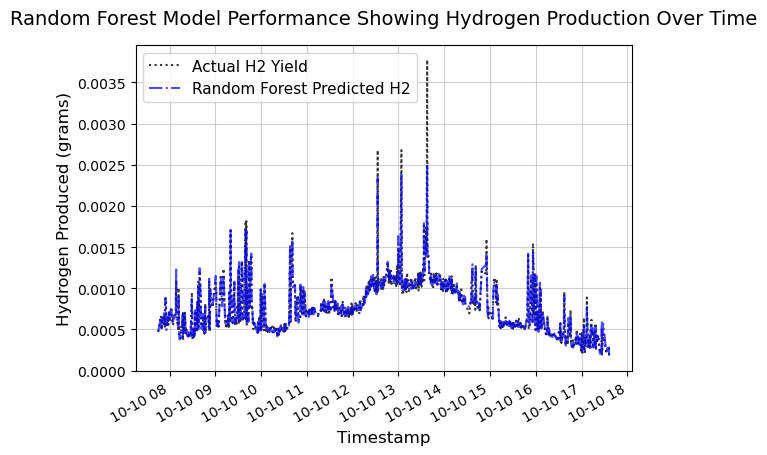

In [ ]:
# Create a graph of the Random Forest Regression prediction over time, to visually prove how well
# the model tracks real-world hydrogen production 
plt.Figure(figsize = (12,6))

proof_df = pd.DataFrame({'Actual': y_test, 'Predicted': rfr_prediction}, 
                        index = X_test.index).sort_index()

plt.plot(proof_df.index, proof_df['Actual'], label= 'Actual H2 Yield',
         color = 'black', alpha = 0.8, linestyle= ':', linewidth=1.5 )

plt.plot(proof_df.index, proof_df['Predicted'], label= 'Random Forest Predicted H2',
         color = 'blue', alpha = 0.7, linestyle= '-.', linewidth=1.5  )


plt.title('Random Forest Model Performance Showing Hydrogen Production Over Time', fontsize=14, pad=15)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Hydrogen Produced (grams)', fontsize=12)
plt.grid(True, alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

plt.gcf().autofmt_xdate() 

# plt.savefig('random_forest_predictions_over_time.png', dpi=300, bbox_inches='tight')

plt.show()